# Import Library

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error

# Load Dataset

In [ ]:
# Load dataset
df = pd.read_csv("Lung Cancer Dataset.csv")
df.head()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


# Exploratory Data Analysis


In [ ]:
# Cek informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   

In [ ]:
# Statisktik deskriptif dataset
df.describe()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE
count,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,0.501200,0.666400,0.6012,0.539800,0.516000,0.439200,55.032043,0.394800,0.80040,0.354200,0.698200,94.991029,0.600600,0.301800,0.204000,0.209600
std,15.799224,0.500049,0.471546,0.4897,0.498463,0.499794,0.496339,7.913083,0.488857,0.39974,0.478318,0.459085,1.481048,0.489824,0.459085,0.403009,0.407064
min,30.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,23.258308,0.000000,0.00000,0.000000,0.000000,89.923133,0.000000,0.000000,0.000000,0.000000
25%,44.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,49.440685,0.000000,1.00000,0.000000,0.000000,93.973176,0.000000,0.000000,0.000000,0.000000
50%,57.000000,1.000000,1.000000,1.0000,1.000000,1.000000,0.000000,55.050421,0.000000,1.00000,0.000000,1.000000,94.974073,1.000000,0.000000,0.000000,0.000000
75%,71.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,60.323320,1.000000,1.00000,1.000000,1.000000,95.989272,1.000000,1.000000,0.000000,0.000000
max,84.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,83.046971,1.000000,1.00000,1.000000,1.000000,99.795786,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Cek nilai yang hilang
df.isna().sum()

AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64

In [ ]:
# cek data duplikat
df.duplicated().sum()

np.int64(0)

In [ ]:
# Cek data unik pada setiap kolom
for col in df.columns:
    print(col, df[col].unique())

AGE [68 81 58 44 72 37 50 48 52 40 53 82 65 69 32 51 31 73 59 67 62 41 54 78
 56 71 57 45 76 80 84 66 36 38 47 33 43 79 55 49 64 46 35 83 63 39 60 77
 74 70 30 34 42 61 75]
GENDER [1 0]
SMOKING [1 0]
FINGER_DISCOLORATION [1 0]
MENTAL_STRESS [1 0]
EXPOSURE_TO_POLLUTION [1 0]
LONG_TERM_ILLNESS [0 1]
ENERGY_LEVEL [57.83117781 47.69483542 59.57743507 ... 61.06349616 48.66287201
 58.2451881 ]
IMMUNE_WEAKNESS [0 1]
BREATHING_ISSUE [0 1]
ALCOHOL_CONSUMPTION [1 0]
THROAT_DISCOMFORT [1 0]
OXYGEN_SATURATION [95.97728696 97.18448348 94.97493934 ... 98.10890144 95.5777729
 94.20693416]
CHEST_TIGHTNESS [1 0]
FAMILY_HISTORY [0 1]
SMOKING_FAMILY_HISTORY [0 1]
STRESS_IMMUNE [0 1]
PULMONARY_DISEASE ['NO' 'YES']


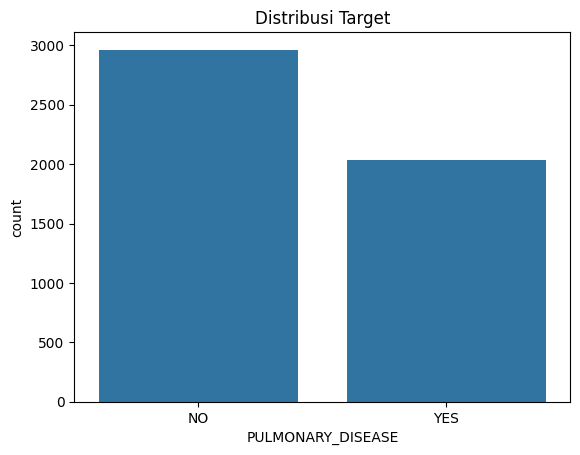

In [ ]:
# Cek distribusi data pada kolom target
sns.countplot(x='PULMONARY_DISEASE', data=df)
plt.title('Distribusi Target')
plt.show()

# Preprocessing Data

In [ ]:
# Encode kolom target
le = LabelEncoder()
df["PULMONARY_DISEASE"] = le.fit_transform(df["PULMONARY_DISEASE"])

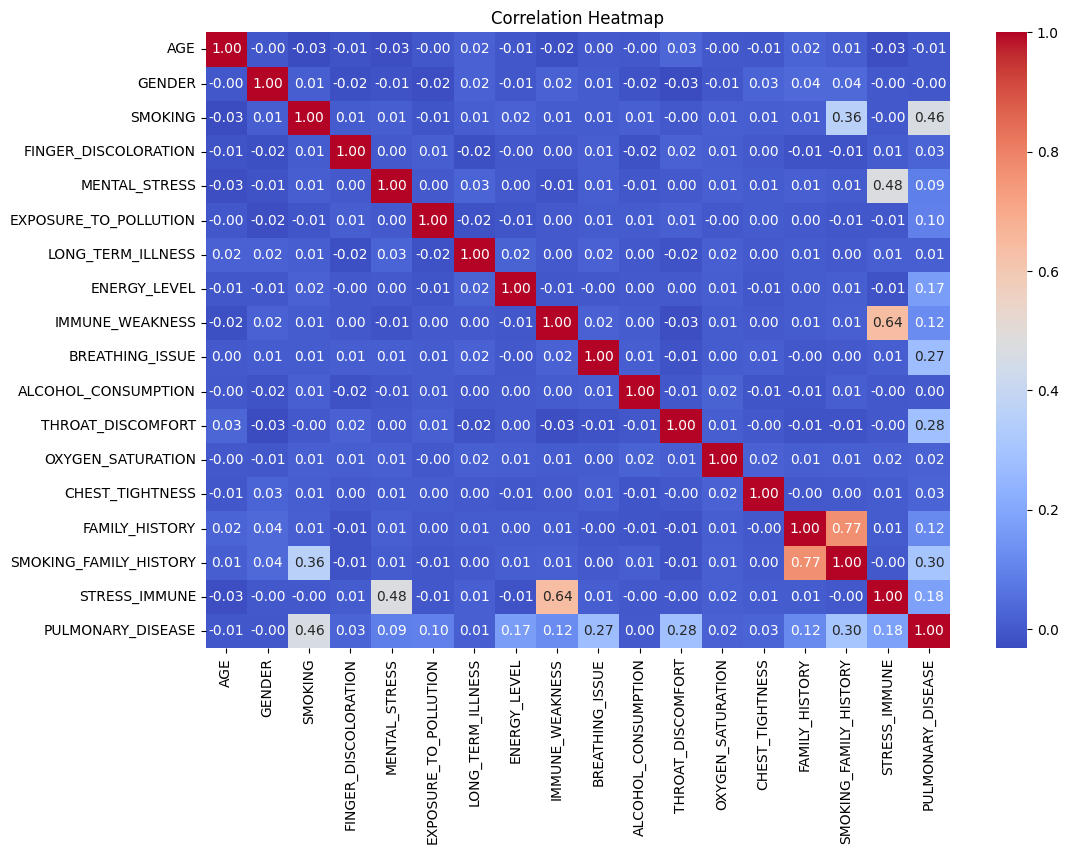

In [ ]:
# Cek korelasi antar fitur
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Modeling 


In [ ]:
# Membagi dataset menjadi fitur dan target
X = df.drop("PULMONARY_DISEASE", axis=1)
y = df["PULMONARY_DISEASE"]

In [ ]:
# Membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Melatih model Random Forest
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Accuracy: 0.911

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92       571
           1       0.90      0.89      0.90       429

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

Training Accuracy : 0.99975
Testing Accuracy  : 0.911


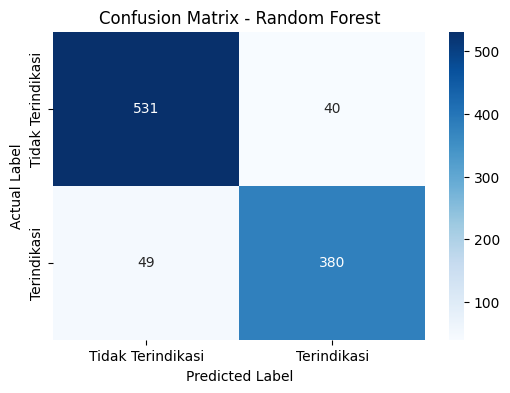

In [ ]:
# Evaluasi model
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Terindikasi', 'Terindikasi'],
    yticklabels=['Tidak Terindikasi', 'Terindikasi']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Berdasarkan hasil confusion matrix, model Random Forest mampu memprediksi 531 data tidak terindikasi dengan benar dan 380 data terindikasi dengan benar. Namun, masih terdapat 40 data yang sebenarnya tidak terindikasi tetapi diprediksi terindikasi, serta 49 data yang sebenarnya terindikasi tetapi diprediksi tidak terindikasi. Secara keseluruhan, model memiliki performa yang cukup baik karena jumlah prediksi benar lebih besar dibandingkan prediksi salah.

In [33]:
# Hyperparameter Tuning dengan Random Search
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
# Definisikan ruang pencarian untuk Random Search
rf = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

# Inisialisasi RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=20, cv=3, n_jobs=-1, verbose=2, random_state=42)
random_search.fit(X_train, y_train)

# Output hasil terbaik
print(f"Best parameters (Random Search): {random_search.best_params_}")
best_rf_random = random_search.best_estimator_

# Evaluasi performa model pada test set
random_search_score = best_rf_random.score(X_test, y_test)
print(f"Accuracy after Random Search: {random_search_score:.2f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters (Random Search): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}
Accuracy after Random Search: 0.91


Training Accuracy : 0.9545
Testing Accuracy  : 0.914

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       571
           1       0.91      0.89      0.90       429

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



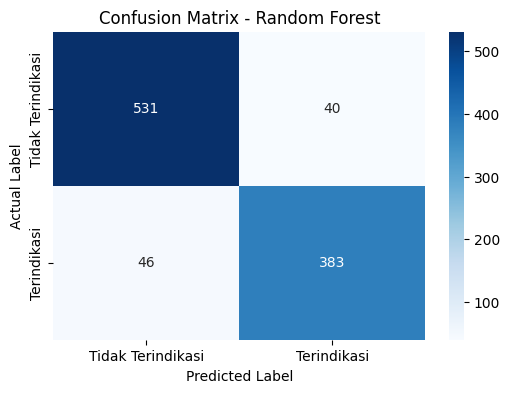

In [34]:
# Melatih model dengan hyperparameter terbaik dari Random Search
model_r = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    criterion='entropy',
    max_features='sqrt'
)

model_r.fit(X_train, y_train)

y_train_pred = model_r.predict(X_train)
y_test_pred = model_r.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Terindikasi', 'Terindikasi'],
    yticklabels=['Tidak Terindikasi', 'Terindikasi']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Berdasarkan perbandingan confusion matrix, model Random Forest setelah dilakukan hyperparameter tuning menggunakan Random Search menunjukkan peningkatan performa dibandingkan model pertama. Pada kelas tidak terindikasi, kedua model memiliki hasil yang sama, yaitu 531 data berhasil diprediksi benar dan 40 data salah diprediksi sebagai terindikasi. Namun, pada kelas terindikasi, model Random Search memberikan hasil yang lebih baik. Jumlah data terindikasi yang berhasil diprediksi benar meningkat dari 380 menjadi 383, sedangkan data terindikasi yang salah diprediksi sebagai tidak terindikasi menurun dari 49 menjadi 46. Hal ini menunjukkan bahwa Random Search membantu model menjadi sedikit lebih baik dalam mengenali kelas terindikasi.

In [49]:
# Prediksi dengan data baru
data_baru = pd.DataFrame([{
    'AGE': 21,
    'GENDER': 1,
    'SMOKING': 1,
    'FINGER_DISCOLORATION': 0,
    'MENTAL_STRESS': 0,
    'EXPOSURE_TO_POLLUTION': 1,
    'LONG_TERM_ILLNESS': 0,
    'ENERGY_LEVEL': 55.0,
    'IMMUNE_WEAKNESS': 0,
    'BREATHING_ISSUE': 1,
    'ALCOHOL_CONSUMPTION': 0,
    'THROAT_DISCOMFORT': 0,
    'OXYGEN_SATURATION': 95.0,
    'CHEST_TIGHTNESS': 0,
    'FAMILY_HISTORY': 0,
    'SMOKING_FAMILY_HISTORY': 0,
    'STRESS_IMMUNE': 0
}])

hasil = model_r.predict(data_baru)

print(hasil)
if (hasil == 1):
    print("Anda terdeteksi memiliki risiko penyakit paru-paru")
else:
    print("Anda tidak terdeteksi memiliki risiko penyakit paru-paru")

[0]
Anda tidak terdeteksi memiliki risiko penyakit paru-paru
